In [1]:
import os
import pandas as pd
from functools import reduce

from Bio import SeqIO

import numpy as np
import matplotlib.pyplot as plt

# Process designs' rank

In [2]:
global_structure_similarity_df = pd.read_csv('../data/6lr7B_grafting_connector_all_temp07_s50_250904/properties/6lr7B_full_foldseek.tsv', sep='\t')
global_sequence_similarity_df = pd.read_csv('../data/6lr7B_grafting_connector_all_temp07_s50_250904/properties/6lr7B_full_mmseqs.tsv', sep='\t')
connector_structure_similarity_df = pd.read_csv('../data/6lr7B_grafting_connector_all_temp07_s50_250904/extract_distance/filter_best/grafted_raw_embeddings.tsv', sep='\t')

connector_structure_similarity_df = connector_structure_similarity_df[['PDB_ID', 'grafted_euclidean_all_raw_embeddings']]

In [3]:
# Duplication and rename - connector searching has processed duplication
global_structure_similarity_df['PDB'] = global_structure_similarity_df['target'].str[:4]
global_structure_similarity_df = global_structure_similarity_df.drop_duplicates(subset='PDB', keep='first').reset_index(drop=True)

global_sequence_similarity_df['PDB'] = global_sequence_similarity_df['target'].str[:4]
global_sequence_similarity_df = global_sequence_similarity_df.drop_duplicates(subset='PDB', keep='first').reset_index(drop=True)

global_structure_similarity_df['id'] = global_structure_similarity_df['query'] + '_' + global_structure_similarity_df['target']
global_sequence_similarity_df['id'] = global_sequence_similarity_df['query'] + '_' + global_sequence_similarity_df['target']
connector_structure_similarity_df['id'] = connector_structure_similarity_df['PDB_ID']

In [4]:
global_structure_similarity_df['id'] = global_structure_similarity_df['query'] + '_' + global_structure_similarity_df['target']
global_sequence_similarity_df['id'] = global_sequence_similarity_df['query'] + '_' + global_sequence_similarity_df['target']
connector_structure_similarity_df['id'] = connector_structure_similarity_df['PDB_ID']

# Process properties

In [5]:
pred_yield = pd.read_csv('../data/6lr7B_grafting_connector_all_temp07_s50_250904/properties/6lr7B_cdr_grafted_all_rp3net.csv')
pred_hydropho_charge = pd.read_csv('../data/6lr7B_grafting_connector_all_temp07_s50_250904/properties/6lr7B_all_hydrophobicity_charge_pi.tsv', sep='\t')

pred_yield.rename(columns={'score': 'Yield'}, inplace=True)
pred_hydropho_charge.rename(columns={'ID': 'id'}, inplace=True)
pred_hydropho_charge.rename(columns={'PI': 'Isoelectric point'}, inplace=True)

In [6]:
dataframes = [pred_yield, pred_hydropho_charge]
merged_properties = reduce(
    lambda left, right: pd.merge(left, right, on='id', how='inner'),
    dataframes
)

selected_merged_properties = merged_properties[
    ['id', 'Yield', 'Isoelectric point']
]

# Merge rank and properties

In [7]:
merged_global_structure_similarity_df = pd.merge(global_structure_similarity_df, selected_merged_properties, how='inner', on='id')
merged_global_sequence_similarity_df = pd.merge(global_sequence_similarity_df, selected_merged_properties, how='inner', on='id')
merged_connector_structure_similarity_df = pd.merge(connector_structure_similarity_df, selected_merged_properties, how='inner', on='id')
# selected_global_connector_structure_similarity_df = pd.merge(selected_global_connector_structure_similarity_df, selected_merged_properties, how='inner', on='id')


Selected top N rows

The first candidate in global similarity was 7sahB, whose sequence same with Lag16, but CDR structure different from Lag16. So we removed it in selection.

In [8]:
merged_global_structure_similarity_df = merged_global_structure_similarity_df[merged_global_structure_similarity_df["id"] != "6lr7B_7sahB"]
merged_global_sequence_similarity_df = merged_global_sequence_similarity_df[merged_global_sequence_similarity_df["id"] != "6lr7B_7sahB"]
merged_connector_structure_similarity_df = merged_connector_structure_similarity_df[merged_connector_structure_similarity_df["id"] != "6lr7B_7sahB"]

In [9]:
top_n = 10
selected_global_structure_similarity_df = merged_global_structure_similarity_df.iloc[:top_n, -6:]
selected_global_sequence_similarity_df = merged_global_sequence_similarity_df.iloc[:top_n, -6:]
selected_connector_structure_similarity_df = merged_connector_structure_similarity_df.iloc[:top_n, -6:]

# selected_global_connector_structure_similarity_df = global_connector_structure_similarity_df[:top_n]['id']

In [10]:
all_selected_ids = []
all_selected_ids.extend(selected_global_structure_similarity_df['id'])
all_selected_ids.extend(selected_global_sequence_similarity_df['id'])
all_selected_ids.extend(selected_connector_structure_similarity_df['id'])
print(all_selected_ids)

# with open('selected_top10_features.txt', 'w') as f:
#     for id in all_selected_ids:
#         f.write(id.split('_')[1] + '\n')

# with open('selected_top10_features.fasta', 'w') as out_f:
#     for record in SeqIO.parse('6lr7B_all_pdb_id.fasta', 'fasta'):
#         if record.id in all_selected_ids:
#             SeqIO.write(record, out_f, 'fasta')

['6lr7B_7saiC', '6lr7B_6zczF', '6lr7B_7z1eFFF', '6lr7B_6zbpFFF', '6lr7B_7z6vZ', '6lr7B_6yz5F', '6lr7B_6z43X', '6lr7B_7z1aE', '6lr7B_8t6iA', '6lr7B_6zh9FFF', '6lr7B_7saiC', '6lr7B_7r24E', '6lr7B_8qf4E', '6lr7B_5gxbB', '6lr7B_8e0eB', '6lr7B_8im1D', '6lr7B_5immB', '6lr7B_5imkB', '6lr7B_5imlB', '6lr7B_5imoB', '6lr7B_3qxtB', '6lr7B_6z2mF', '6lr7B_6z43X', '6lr7B_5m14D', '6lr7B_7om5B', '6lr7B_7nowA', '6lr7B_4nbyB', '6lr7B_8cyjD', '6lr7B_8p88C', '6lr7B_6gkdQ']


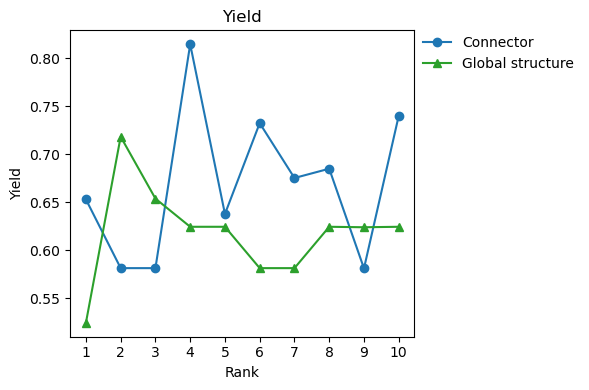

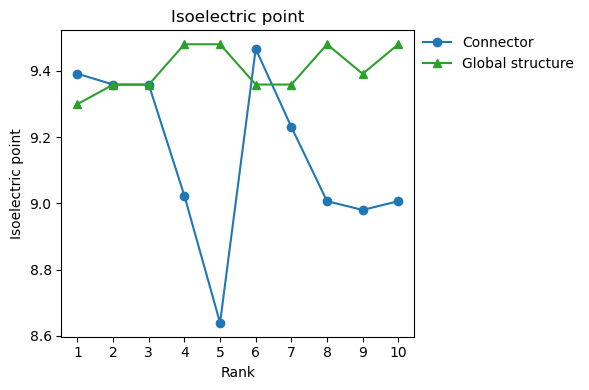

In [11]:
labels = ['Connector', 'Global structure', 'Global sequence']
colors = ['tab:blue', 'tab:orange', 'tab:green']
columns = ['Yield', 'Isoelectric point']

# 行数和 x 轴数据：1..N
N = len(selected_connector_structure_similarity_df)
x = np.arange(1, N + 1)

for col in columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # 画三条折线
    ax.plot(x, selected_connector_structure_similarity_df[col], label=labels[0], marker='o', color=colors[0])
    # ax.plot(x, selected_global_sequence_similarity_df[col], label=labels[2], marker='s', color=colors[1])
    ax.plot(x, selected_global_structure_similarity_df[col], label=labels[1], marker='^', color=colors[2])
    
    # 设置 x 轴刻度：每隔 5 个
    ax.set_xticks(np.arange(1, N+1, 1))
    ax.set_xticklabels([str(i) for i in np.arange(1, N+1, 1)])
    ax.xaxis.set_visible(True)
    
    # 标题与 y 轴
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.set_xlabel('Rank')
    
    # 把图例放到右侧外面
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        frameon=False
    )
    fig.subplots_adjust(right=0.75)
    
    plt.tight_layout()

    savepath = f"../figures/compare_propeties_{col}.png"
    plt.savefig(savepath, dpi=600, bbox_inches='tight')

    plt.show()
